# 03 - Indexing Contract

Notebook operativo per mostrare la metodologia di indicizzazione Qdrant.

La parte demo usa un dataset minimo, un embedder deterministico e Qdrant in-memory: serve a verificare payload, filtri, artifact e grafici senza scaricare modelli. La full run reale e presente nell'ultima cella ed e disattivata di default.

In [1]:
from __future__ import annotations

import json
import os
import math
import tempfile
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from qdrant_client import QdrantClient

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from legal_rag.indexing import IndexingConfig, debug_utopia_embedding_connection, run_indexing_pipeline, search_index, validate_clean_dataset

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
PROJECT_ROOT

PosixPath('/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite')

## 1. Verifica del dataset pulito reale

Questa cella non indicizza nulla: controlla solo se il dataset prodotto dallo step 01 rispetta il contratto richiesto dallo step 03.

In [2]:
clean_dataset_dir = PROJECT_ROOT / "data" / "laws_dataset_clean"
validation = validate_clean_dataset(clean_dataset_dir, strict=False)
validation_summary = validation.to_dict()
validation_summary

{'dataset_dir': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean',
 'required_files': {'manifest.json': True,
  'chunks.jsonl': True,
  'laws.jsonl': True,
  'articles.jsonl': True,
  'edges.jsonl': True},
 'counts': {'laws': 3145, 'articles': 17774, 'edges': 35159, 'chunks': 76467},
 'missing_chunk_fields': {'article_id': 0,
  'article_label_norm': 0,
  'article_status': 0,
  'chunk_id': 0,
  'inbound_law_ids': 0,
  'index_views': 0,
  'law_date': 0,
  'law_id': 0,
  'law_number': 0,
  'law_status': 0,
  'law_title': 0,
  'outbound_law_ids': 0,
  'passage_id': 0,
  'passage_label': 0,
  'related_law_ids': 0,
  'relation_types': 0,
  'source_file': 0,
  'structure_path': 0,
  'text': 0,
  'text_for_embedding': 0},
 'duplicate_chunk_ids': [],
 'errors': [],
 'warnings': [],
 'ok': True}

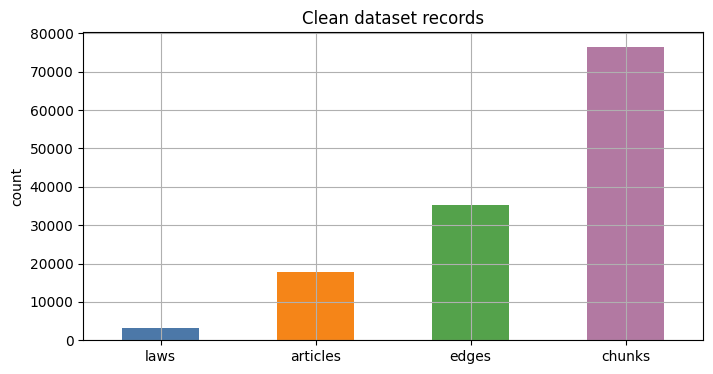

In [3]:
counts = pd.Series(validation_summary["counts"], name="records")
ax = counts.plot(kind="bar", color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"])
ax.set_title("Clean dataset records")
ax.set_ylabel("count")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.show()

## 2. Dataset demo

La demo costruisce tre chunk fittizi ma conformi al payload contract. In questo modo il notebook mostra il processo senza dipendere da credenziali, modelli o download.

In [4]:
def write_json(path: Path, data: dict) -> None:
    path.write_text(json.dumps(data, ensure_ascii=False, indent=2, sort_keys=True) + "\n", encoding="utf-8")

def write_jsonl(path: Path, rows: list[dict]) -> None:
    path.write_text("".join(json.dumps(row, ensure_ascii=False, sort_keys=True) + "\n" for row in rows), encoding="utf-8")

def demo_chunk(chunk_id: str, text: str, *, law_id: str, article: int, relation_types: list[str]) -> dict:
    article_id = f"{law_id}#art:{article}"
    return {
        "chunk_id": chunk_id,
        "passage_id": f"{article_id}#p:c1",
        "article_id": article_id,
        "law_id": law_id,
        "text": text,
        "text_for_embedding": f"[LR demo] Test law | Art. {article} | c1 |\n\n{text}",
        "law_date": "2000-01-01",
        "law_number": int(law_id.rsplit(':', 1)[-1]),
        "law_title": f"Legge regionale demo n. {law_id.rsplit(':', 1)[-1]}",
        "law_status": "current",
        "article_status": "current",
        "article_label_norm": str(article),
        "passage_label": "c1",
        "structure_path": "",
        "source_file": f"demo_{chunk_id}.html",
        "index_views": ["current", "historical"],
        "related_law_ids": [],
        "inbound_law_ids": [],
        "outbound_law_ids": [],
        "relation_types": relation_types,
    }

demo_root = Path(tempfile.mkdtemp(prefix="legal_rag_indexing_demo_"))
chunks = [
    demo_chunk("demo-c1", "Contributi regionali per formazione professionale.", law_id="vda:lr:2000-01-01:1", article=1, relation_types=["REFERENCES"]),
    demo_chunk("demo-c2", "Tutela dell'ambiente e procedure autorizzative.", law_id="vda:lr:2000-01-01:2", article=2, relation_types=["AMENDS"]),
    demo_chunk("demo-c3", "Disposizioni finanziarie e rendicontazione.", law_id="vda:lr:2000-01-01:3", article=3, relation_types=[]),
]
write_jsonl(demo_root / "chunks.jsonl", chunks)
write_jsonl(demo_root / "laws.jsonl", [{"law_id": row["law_id"]} for row in chunks])
write_jsonl(demo_root / "articles.jsonl", [{"article_id": row["article_id"]} for row in chunks])
write_jsonl(demo_root / "edges.jsonl", [{"edge_id": "demo-edge-1"}])
write_json(demo_root / "manifest.json", {
    "ready_for_indexing": True,
    "source_hash": "demo-source-hash",
    "counts": {"laws": 3, "articles": 3, "edges": 1, "chunks": 3},
    "output_hashes": {"chunks": "demo-chunks-hash"},
})
demo_root

PosixPath('/var/folders/9b/g7kf969n2kl03xm30zpvmkm40000gp/T/legal_rag_indexing_demo_1x2a4xi1')

## 3. Embedder deterministico

Espone sia dense vectors sia sparse vectors per dimostrare lo schema hybrid senza caricare `BAAI/bge-m3`.

In [5]:
class DemoEmbedder:
    @property
    def model_name(self) -> str:
        return "deterministic-demo"

    def embed_texts(self, texts: list[str]) -> list[list[float]]:
        vectors = []
        for text in texts:
            length = float(len(text))
            vowels = float(sum(1 for char in text.lower() if char in "aeiouàèéìòù"))
            words = float(len(text.split()))
            vectors.append([length, vowels, words, 1.0])
        return vectors

    def embed_sparse_texts(self, texts: list[str]) -> list[tuple[list[int], list[float]]]:
        vectors = []
        for text in texts:
            tokens = sorted(set(word.strip(".,;:()[]").lower() for word in text.split() if word.strip()))
            indices = [abs(hash(token)) % 10000 for token in tokens]
            values = [1.0 + math.log1p(text.lower().count(token)) for token in tokens]
            pairs = sorted(zip(indices, values), key=lambda item: item[0])
            vectors.append(([idx for idx, _ in pairs], [value for _, value in pairs]))
        return vectors

embedder = DemoEmbedder()
embedder.embed_texts([chunks[0]["text_for_embedding"]]), embedder.embed_sparse_texts([chunks[0]["text_for_embedding"]])

([[86.0, 26.0, 15.0, 1.0]],
 [([2183,
    2225,
    2725,
    3351,
    4083,
    4968,
    6392,
    6800,
    7458,
    7564,
    8678,
    9355,
    9859],
   [2.386294361119891,
    2.09861228866811,
    1.6931471805599454,
    1.6931471805599454,
    1.6931471805599454,
    1.6931471805599454,
    1.6931471805599454,
    1.6931471805599454,
    1.6931471805599454,
    1.6931471805599454,
    1.6931471805599454,
    1.6931471805599454,
    1.6931471805599454])])

## 4. Run demo completa

La stessa pipeline usata dalla full run crea collection, payload indexes, punti Qdrant e artifact. Qui il client e in-memory.

In [6]:
demo_client = QdrantClient(":memory:")
demo_run_id = "notebook_demo_" + datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")

demo_config = IndexingConfig(
    clean_dataset_dir=str(demo_root),
    runs_dir=str(PROJECT_ROOT / "data" / "indexing_runs"),
    collection_name="legal_chunks_notebook_demo",
    chunk_selection_mode="sample",
    sample_size=3,
    run_id=demo_run_id,
    embedding_backend="local",
    embedding_model="deterministic-demo",
    hybrid_enabled=True,
    diagnostic_queries=["contributi formazione", "ambiente autorizzazioni", "rendicontazione"],
)

demo_manifest = run_indexing_pipeline(demo_config, embedder=embedder, client=demo_client)
demo_manifest

/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/src/legal_rag/indexing/qdrant_store.py:132: UserWarning: Payload indexes have no effect in the local Qdrant. Please use server Qdrant if you need payload indexes.
  client.create_payload_index(


{'schema_version': 'indexing-contract-v1',
 'created_at': '2026-05-05T08:48:35Z',
 'run_id': 'notebook_demo_20260505_084835',
 'config': {'clean_dataset_dir': '/var/folders/9b/g7kf969n2kl03xm30zpvmkm40000gp/T/legal_rag_indexing_demo_1x2a4xi1',
  'index_dir': 'data/indexes/qdrant',
  'runs_dir': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/indexing_runs',
  'collection_name': 'legal_chunks_notebook_demo',
  'qdrant_url': None,
  'force_rebuild': False,
  'chunk_selection_mode': 'sample',
  'sample_size': 3,
  'strict': True,
  'run_id': 'notebook_demo_20260505_084835',
  'env_file': '.env',
  'embedding_backend': 'local',
  'embedding_model': 'deterministic-demo',
  'embedding_dim': None,
  'hybrid_enabled': True,
  'utopia_base_url': 'https://utopia.hpc4ai.unito.it/api',
  'utopia_embed_url': 'https://utopia.hpc4ai.unito.it/ollama/api/embeddings',
  'utopia_embed_api_mode': 'ollama',
  'batch_size': 64,
  'embedding_ti

In [7]:
manifest_summary = {
    "ready_for_retrieval": demo_manifest["ready_for_retrieval"],
    "selected_count": demo_manifest["selected_count"],
    "indexed_count": demo_manifest["indexed_count"],
    "collection_points_count": demo_manifest["collection_points_count"],
    "hybrid_enabled": demo_manifest["embedding"]["hybrid_enabled"],
    "vector_size": demo_manifest["embedding"]["vector_size"],
}
manifest_summary

{'ready_for_retrieval': True,
 'selected_count': 3,
 'indexed_count': 3,
 'collection_points_count': 3,
 'hybrid_enabled': True,
 'vector_size': 4}

## 5. Payload profile

Il grafico mostra la copertura dei campi payload obbligatori. In una run valida la copertura deve essere completa.

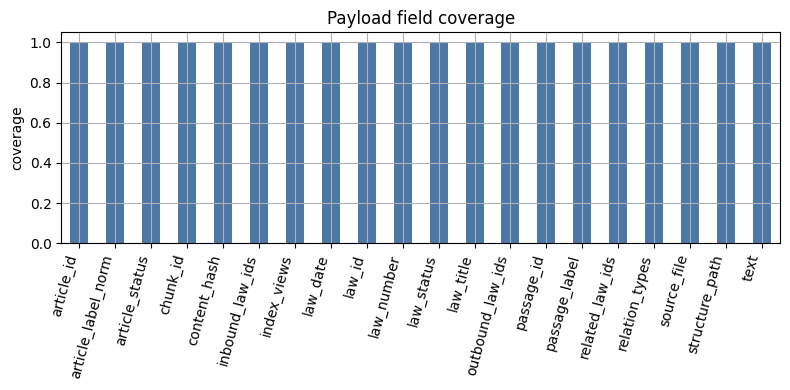

In [8]:
run_dir = PROJECT_ROOT / "data" / "indexing_runs" / demo_run_id
payload_profile = json.loads((run_dir / "payload_profile.json").read_text(encoding="utf-8"))
coverage = pd.Series({field: info["present_coverage"] for field, info in payload_profile["fields"].items()}).sort_index()
ax = coverage.plot(kind="bar", color="#4C78A8")
ax.set_title("Payload field coverage")
ax.set_ylabel("coverage")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

## 6. Query diagnostiche

Queste query verificano che dense/hybrid retrieval e filtri sui metadati restituiscano payload coerenti.

In [9]:
diagnostics = json.loads((run_dir / "diagnostic_queries.json").read_text(encoding="utf-8"))
rows = []
for query_row in diagnostics["queries"]:
    for hit in query_row.get("hits", []):
        rows.append({"query": query_row["query"], "chunk_id": hit["chunk_id"], "score": hit["score"], "law_id": hit["law_id"]})
retrieval_df = pd.DataFrame(rows)
retrieval_df

,query,chunk_id,score,law_id
0,contributi formazione,demo-c1,0.833333,vda:lr:2000-01-01:1
1,contributi formazione,demo-c3,0.500000,vda:lr:2000-01-01:3
2,contributi formazione,demo-c2,0.250000,vda:lr:2000-01-01:2
3,ambiente autorizzazioni,demo-c3,0.500000,vda:lr:2000-01-01:3
4,ambiente autorizzazioni,demo-c1,0.333333,vda:lr:2000-01-01:1
5,ambiente autorizzazioni,demo-c2,0.250000,vda:lr:2000-01-01:2
6,rendicontazione,demo-c3,1.000000,vda:lr:2000-01-01:3
7,rendicontazione,demo-c1,0.333333,vda:lr:2000-01-01:1
8,rendicontazione,demo-c2,0.250000,vda:lr:2000-01-01:2


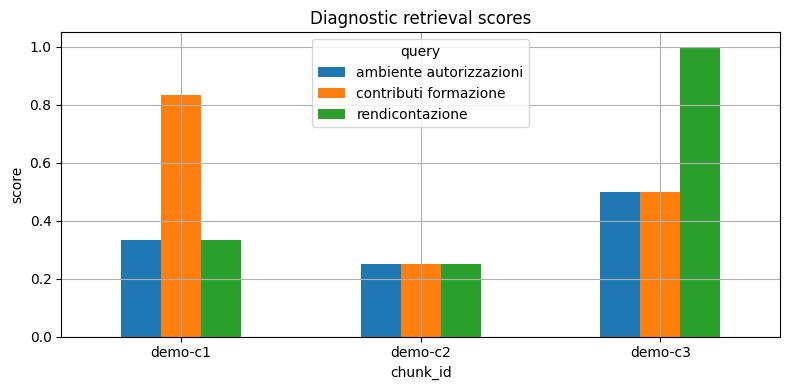

In [10]:
if not retrieval_df.empty:
    ax = retrieval_df.pivot_table(index="chunk_id", columns="query", values="score", aggfunc="max").plot(kind="bar")
    ax.set_title("Diagnostic retrieval scores")
    ax.set_ylabel("score")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [11]:
hits = search_index(
    demo_client,
    collection_name=demo_manifest["collection_name"],
    embedder=embedder,
    query="formazione professionale",
    law_status="current",
    index_view="current",
    retrieval_mode="hybrid",
    limit=2,
)
[{"chunk_id": hit.chunk_id, "score": hit.score, "law_id": hit.payload["law_id"], "text": hit.text} for hit in hits]

[{'chunk_id': 'demo-c1',
  'score': 0.8333333333333333,
  'law_id': 'vda:lr:2000-01-01:1',
  'text': 'Contributi regionali per formazione professionale.'},
 {'chunk_id': 'demo-c3',
  'score': 0.5,
  'law_id': 'vda:lr:2000-01-01:3',
  'text': 'Disposizioni finanziarie e rendicontazione.'}]

## 7. Full indexing reale

Questa cella usa il modello embedding fornito da Utopia e scrive su Qdrant server Docker (`http://127.0.0.1:6333`). Utopia in questo step e dense-only, quindi `hybrid_enabled=False`.

In [12]:
!docker compose -f docker-compose.qdrant.yml up -d

open /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/notebooks/docker-compose.qdrant.yml: no such file or directory


In [13]:
RUN_FULL_INDEX = True

progress_events = []

def show_indexing_progress(event: dict) -> None:
    progress_events.append(event)
    if event.get("event") == "sync_started":
        print(
            f"Indexing started: selected={event['selected']}, "
            f"skipped={event['skipped']}, to_process={event['to_process']}, "
            f"batch_size={event['batch_size']}",
            flush=True,
        )
    elif event.get("event") == "batch_finished":
        eta = event.get("eta_seconds")
        eta_text = f", eta={eta:.0f}s" if isinstance(eta, (int, float)) else ""
        print(
            f"batch {event['batch']}/{event['batch_total']} - "
            f"{event['processed']}/{event['selected']} ({event['percent']}%) - "
            f"rate={event['rate_chunks_per_second']}/s - "
            f"upserted={event['upserted']} skipped={event['skipped']} failures={event['failures']}"
            f"{eta_text}",
            flush=True,
        )

if RUN_FULL_INDEX:
    full_config = IndexingConfig(
        clean_dataset_dir=str(PROJECT_ROOT / "data" / "laws_dataset_clean"),
        qdrant_url="http://127.0.0.1:6333",
        runs_dir=str(PROJECT_ROOT / "data" / "indexing_runs"),
        collection_name="legal_chunks",  # use "legal_chunks" for full indexing
        chunk_selection_mode="full",  # use "sample" for sample indexing
        force_rebuild=True,
        embedding_backend="utopia",
        embedding_model=os.getenv("UTOPIA_EMBED_MODEL", "SLURM.nomic-embed-text:latest"),
        hybrid_enabled=False,
        batch_size=128,
        upload_batch_size=128,
        embedding_timeout_seconds=120,
    )
    print(debug_utopia_embedding_connection(full_config), flush=True)
    full_manifest = run_indexing_pipeline(
        full_config,
        progress_callback=show_indexing_progress,
    )
    full_manifest
else:
    print("Full indexing skipped. Start Qdrant Docker, set UTOPIA_API_KEY, then set RUN_FULL_INDEX = True.")

{'backend': 'utopia', 'model': 'SLURM.nomic-embed-text:latest', 'base_url': 'https://utopia.hpc4ai.unito.it/api', 'embed_url': 'https://utopia.hpc4ai.unito.it/ollama/api/embeddings', 'success': True, 'model_catalog': {'ok': True, 'root_url': 'https://utopia.hpc4ai.unito.it', 'base_url': 'https://utopia.hpc4ai.unito.it/api', 'tags_url': 'https://utopia.hpc4ai.unito.it/ollama/api/tags', 'models': ['deepseek-r1:70b-llama-distill-q8_0', 'gemma3:27b-it-fp16', 'gpt-oss:120b', 'gpt-oss:20b', 'mxbai-embed-large:latest', 'nomic-embed-text:latest', 'qwen3-coder-next:q8_0', 'qwen3-embedding:latest', 'qwen3:32b-fp16-utopia'], 'embedding_like_models': ['mxbai-embed-large:latest', 'nomic-embed-text:latest', 'qwen3-embedding:latest'], 'status_code': 200, 'count': 9}, 'resolved_embedder': 'UtopiaOllamaEmbedder', 'vector_size': 768, 'active_endpoint': 'https://utopia.hpc4ai.unito.it/ollama/api/embed', 'active_variant': 'input_list', 'latency_ms': 638.8}
Indexing started: selected=76467, skipped=0, to_p